In [1]:

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

import joblib

plt.style.use("ggplot")

In [2]:
rfm = pd.read_csv("customer_segments.csv")

rfm.head()

,Customer ID,Recency,Frequency,Monetary,Total_Items,Average_Order_Value,CLV,Cluster,Segment
0,12346.0,326,12,77556.46,34,6463.038333,930677.52,1,Loyal
1,12347.0,2,8,4921.53,222,615.191250,39372.24,1,Loyal
2,12348.0,75,5,2019.40,51,403.880000,10097.00,1,Loyal
3,12349.0,19,4,4428.69,175,1107.172500,17714.76,1,Loyal
4,12350.0,310,1,334.40,17,334.400000,334.40,0,High Value


In [3]:
# Customers inactive for more than 180 days are considered churned

rfm["Churn"] = np.where(
    rfm["Recency"] > 180,
    1,
    0
)

rfm.head()

,Customer ID,Recency,Frequency,Monetary,Total_Items,Average_Order_Value,CLV,Cluster,Segment,Churn
0,12346.0,326,12,77556.46,34,6463.038333,930677.52,1,Loyal,1
1,12347.0,2,8,4921.53,222,615.191250,39372.24,1,Loyal,0
2,12348.0,75,5,2019.40,51,403.880000,10097.00,1,Loyal,0
3,12349.0,19,4,4428.69,175,1107.172500,17714.76,1,Loyal,0
4,12350.0,310,1,334.40,17,334.400000,334.40,0,High Value,1


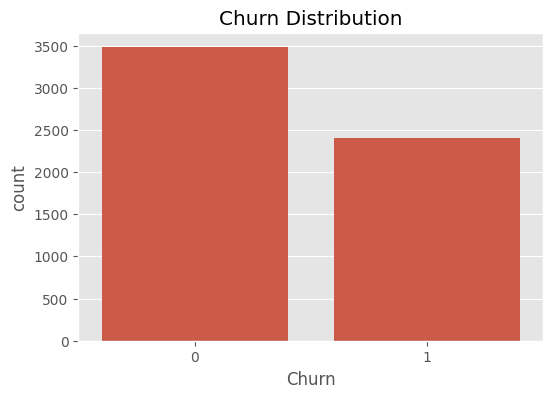

Churn
0    3478
1    2400
Name: count, dtype: int64


In [4]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="Churn",
    data=rfm
)

plt.title("Churn Distribution")

plt.show()

print(rfm["Churn"].value_counts())

In [5]:
features = [
    "Recency",
    "Frequency",
    "Monetary",
    "Total_Items",
    "Average_Order_Value",
    "CLV"
]

X = rfm[features]

y = rfm["Churn"]

In [6]:
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    random_state=42,

    stratify=y

)

print(X_train.shape)
print(X_test.shape)

(4702, 6)
(1176, 6)


In [7]:
lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr.fit(
    X_train,
    y_train
)

lr_pred = lr.predict(X_test)

lr_prob = lr.predict_proba(X_test)[:,1]

In [8]:
print("Accuracy :",accuracy_score(y_test,lr_pred))

print("Precision :",precision_score(y_test,lr_pred))

print("Recall :",recall_score(y_test,lr_pred))

print("F1 :",f1_score(y_test,lr_pred))

print("ROC AUC :",roc_auc_score(y_test,lr_prob))

Accuracy : 0.9991496598639455
Precision : 1.0
Recall : 0.9979166666666667
F1 : 0.9989572471324296
ROC AUC : 0.9998742816091954


In [9]:
rf = RandomForestClassifier(

    n_estimators=200,

    random_state=42

)

rf.fit(
    X_train,
    y_train
)

rf_pred = rf.predict(X_test)

rf_prob = rf.predict_proba(X_test)[:,1]

In [10]:
print("Accuracy :",accuracy_score(y_test,rf_pred))

print("Precision :",precision_score(y_test,rf_pred))

print("Recall :",recall_score(y_test,rf_pred))

print("F1 :",f1_score(y_test,rf_pred))

print("ROC AUC :",roc_auc_score(y_test,rf_prob))

Accuracy : 0.9991496598639455
Precision : 1.0
Recall : 0.9979166666666667
F1 : 0.9989572471324296
ROC AUC : 1.0


In [11]:
print(classification_report(
    y_test,
    rf_pred
))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       696
           1       1.00      1.00      1.00       480

    accuracy                           1.00      1176
   macro avg       1.00      1.00      1.00      1176
weighted avg       1.00      1.00      1.00      1176



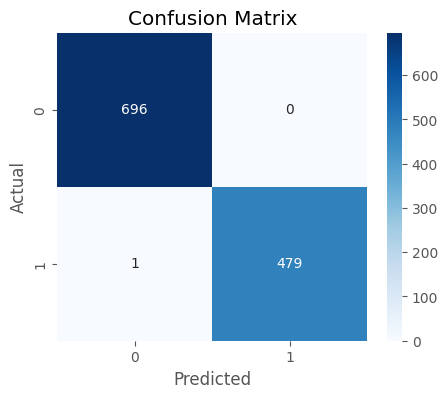

In [12]:
cm = confusion_matrix(
    y_test,
    rf_pred
)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

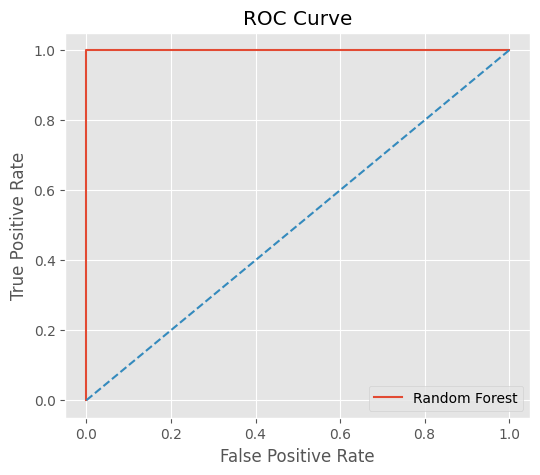

In [13]:
fpr,tpr,_ = roc_curve(
    y_test,
    rf_prob
)

plt.figure(figsize=(6,5))

plt.plot(
    fpr,
    tpr,
    label="Random Forest"
)

plt.plot(
    [0,1],
    [0,1],
    "--"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

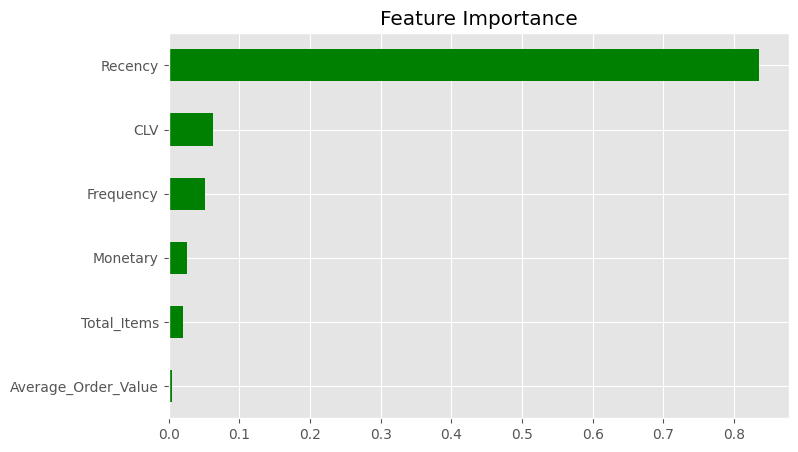

In [14]:
importance = pd.Series(

    rf.feature_importances_,

    index=features

).sort_values()

plt.figure(figsize=(8,5))

importance.plot(
    kind="barh",
    color="green"
)

plt.title("Feature Importance")

plt.show()

In [15]:
comparison = pd.DataFrame({

"Model":[
"Logistic Regression",
"Random Forest"
],

"Accuracy":[
accuracy_score(y_test,lr_pred),
accuracy_score(y_test,rf_pred)
],

"Precision":[
precision_score(y_test,lr_pred),
precision_score(y_test,rf_pred)
],

"Recall":[
recall_score(y_test,lr_pred),
recall_score(y_test,rf_pred)
],

"F1":[
f1_score(y_test,lr_pred),
f1_score(y_test,rf_pred)
],

"ROC AUC":[
roc_auc_score(y_test,lr_prob),
roc_auc_score(y_test,rf_prob)
]

})

comparison

,Model,Accuracy,Precision,Recall,F1,ROC AUC
0,Logistic Regression,0.99915,1.0,0.997917,0.998957,0.999874
1,Random Forest,0.99915,1.0,0.997917,0.998957,1.000000


In [16]:
joblib.dump(
    rf,
    "churn_model.pkl"
)

print("Random Forest model saved successfully!")

Random Forest model saved successfully!


In [17]:
rfm["Churn_Probability"] = rf.predict_proba(X)[:,1]

rfm.head()

,Customer ID,Recency,Frequency,Monetary,Total_Items,Average_Order_Value,CLV,Cluster,Segment,Churn,Churn_Probability
0,12346.0,326,12,77556.46,34,6463.038333,930677.52,1,Loyal,1,0.985
1,12347.0,2,8,4921.53,222,615.191250,39372.24,1,Loyal,0,0.005
2,12348.0,75,5,2019.40,51,403.880000,10097.00,1,Loyal,0,0.005
3,12349.0,19,4,4428.69,175,1107.172500,17714.76,1,Loyal,0,0.005
4,12350.0,310,1,334.40,17,334.400000,334.40,0,High Value,1,1.000


In [18]:
high_risk = rfm[
    rfm["Churn_Probability"]>0.80
]

high_risk.head()

print("High Risk Customers :",len(high_risk))

High Risk Customers : 2398


In [19]:
rfm.to_csv(
    "customer_churn_predictions.csv",
    index=False
)

print("Predictions saved.")

Predictions saved.


In [20]:
print("="*60)

print("CHURN INSIGHTS")

print("="*60)

print("• Customers with high recency are most likely to churn.")

print("• High-value customers with increasing recency should receive retention offers.")

print("• Loyalty programs can reduce churn among repeat customers.")

print("• Personalized email campaigns should target high-risk customers.")

print("• Churn probability scores can prioritize customer retention efforts.")

CHURN INSIGHTS
• Customers with high recency are most likely to churn.
• High-value customers with increasing recency should receive retention offers.
• Loyalty programs can reduce churn among repeat customers.
• Personalized email campaigns should target high-risk customers.
• Churn probability scores can prioritize customer retention efforts.
